# Stage 2: Data Preparation & Clustering Analysis
### Customer Churn Analysis for a Telecommunications Company

This notebook covers the Stage 2 deliverables:
- **Data Preparation**: cleaning, encoding, train/test split, scaling
- **Clustering Analysis**: elbow method, K-Means training, cluster visualization and interpretation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib

pd.set_option('display.max_columns', None)

## 1. Load the Dataset

In [2]:
df = pd.read_csv('Dataset_ATS_v2.csv')
print("Shape:", df.shape)
df.head()

Shape: (7043, 10)


,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,Contract,MonthlyCharges,Churn
0,Female,0,No,1,No,No,DSL,Month-to-month,25,Yes
1,Male,0,No,41,Yes,No,DSL,One year,25,No
2,Female,0,Yes,52,Yes,No,DSL,Month-to-month,19,No
3,Female,0,No,1,Yes,No,DSL,One year,76,Yes
4,Male,0,No,67,Yes,No,Fiber optic,Month-to-month,51,No


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   gender           7043 non-null   object
 1   SeniorCitizen    7043 non-null   int64 
 2   Dependents       7043 non-null   object
 3   tenure           7043 non-null   int64 
 4   PhoneService     7043 non-null   object
 5   MultipleLines    7043 non-null   object
 6   InternetService  7043 non-null   object
 7   Contract         7043 non-null   object
 8   MonthlyCharges   7043 non-null   int64 
 9   Churn            7043 non-null   object
dtypes: int64(3), object(7)
memory usage: 550.4+ KB


## 2. Data Preparation

### 2.1 Check for Missing Data

In [4]:
print("Missing values per column:")
print(df.isnull().sum())

Missing values per column:
gender             0
SeniorCitizen      0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
Contract           0
MonthlyCharges     0
Churn              0
dtype: int64


In [ ]:
categorical_cols = ['gender', 'Dependents', 'PhoneService', 'MultipleLines',
                     'InternetService', 'Contract', 'Churn']

for col in categorical_cols:
    blanks = (df[col].astype(str).str.strip() == '').sum()
    print(col, "-> blank values:", blanks)

print("\nNo missing or blank values were found. The dataset is already clean.")

gender -> blank values: 0
Dependents -> blank values: 0
PhoneService -> blank values: 0
MultipleLines -> blank values: 0
InternetService -> blank values: 0
Contract -> blank values: 0
Churn -> blank values: 0

No missing or blank values were found. The dataset is already clean.


### 2.2 Encode Categorical Variables

In [ ]:
df_encoded = df.copy()

df_encoded['gender'] = df_encoded['gender'].map({'Female': 0, 'Male': 1})
df_encoded['Dependents'] = df_encoded['Dependents'].map({'No': 0, 'Yes': 1})
df_encoded['PhoneService'] = df_encoded['PhoneService'].map({'No': 0, 'Yes': 1})
df_encoded['MultipleLines'] = df_encoded['MultipleLines'].map({'No': 0, 'Yes': 1})
df_encoded['InternetService'] = df_encoded['InternetService'].map({'DSL': 0, 'Fiber optic': 1})
df_encoded['Churn'] = df_encoded['Churn'].map({'No': 0, 'Yes': 1})

df_encoded = pd.get_dummies(df_encoded, columns=['Contract'], drop_first=True)

df_encoded.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Churn,Contract_One year,Contract_Two year
0,0,0,0,1,0,0,0,25,1,False,False
1,1,0,0,41,1,0,0,25,0,True,False
2,0,0,1,52,1,0,0,19,0,False,False
3,0,0,0,1,1,0,0,76,1,True,False
4,1,0,0,67,1,0,1,51,0,False,False


### 2.3 Split into Training and Testing Sets

In [7]:
X = df_encoded.drop('Churn', axis=1)
y = df_encoded['Churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Training set size:", X_train.shape)
print("Testing set size: ", X_test.shape)

Training set size: (5634, 10)
Testing set size:  (1409, 10)


### 2.4 Feature Scaling

Only `tenure` and `MonthlyCharges` are continuous numeric features, so only these two are scaled.
The scaler is fit on the training set only, and then used to transform the test set — this avoids data leakage.

In [8]:
scaler = StandardScaler()
numeric_cols = ['tenure', 'MonthlyCharges']

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

X_train_scaled[numeric_cols] = scaler.fit_transform(X_train[numeric_cols])
X_test_scaled[numeric_cols] = scaler.transform(X_test[numeric_cols])

X_train_scaled.head()

,gender,SeniorCitizen,Dependents,tenure,PhoneService,MultipleLines,InternetService,MonthlyCharges,Contract_One year,Contract_Two year
3757,1,0,1,-1.276682,1,0,0,-0.149881,False,True
3165,0,0,0,-0.096089,1,0,0,-0.315125,True,False
4912,0,1,0,0.555273,1,1,1,1.172071,False,False
3877,1,0,0,0.433143,1,0,0,0.048412,True,False
3818,1,0,0,-1.276682,1,1,1,-1.471834,False,True


### 2.5 Save the Prepared Data

In [ ]:
df_encoded.to_csv('preprocessed_dataset.csv', index=False)

df_scaled_full = df_encoded.copy()
df_scaled_full[numeric_cols] = scaler.transform(df_encoded[numeric_cols])
df_scaled_full.to_csv('preprocessed_dataset_scaled.csv', index=False)

train_set = X_train_scaled.copy()
train_set['Churn'] = y_train.values
train_set.to_csv('train_set.csv', index=False)

test_set = X_test_scaled.copy()
test_set['Churn'] = y_test.values
test_set.to_csv('test_set.csv', index=False)

print("Saved files:")
print("- preprocessed_dataset.csv (encoded, unscaled)")
print("- preprocessed_dataset_scaled.csv (encoded, scaled)")
print("- train_set.csv (scaled)")
print("- test_set.csv (scaled)")

Saved files:
- preprocessed_dataset.csv (encoded, unscaled)
- preprocessed_dataset_scaled.csv (encoded, scaled)
- train_set.csv (scaled)
- test_set.csv (scaled)


## 3. Clustering Analysis

### 3.1 Finding the Optimal Number of Clusters (Elbow Method)

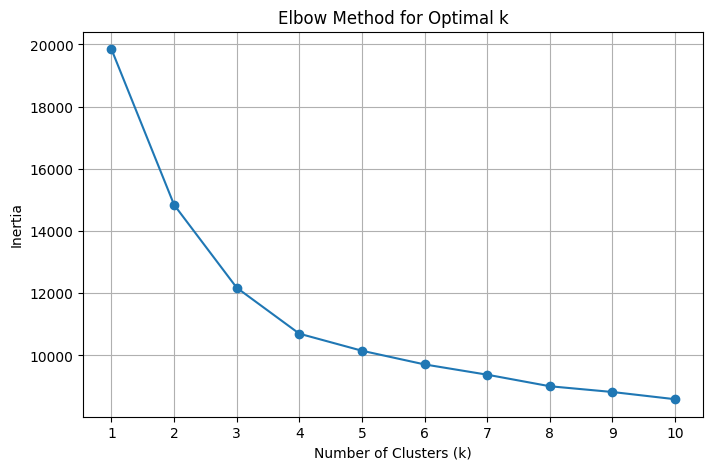

In [10]:
cluster_data = X_train_scaled

inertia_values = []
k_range = range(1, 11)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(cluster_data)
    inertia_values.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.xticks(list(k_range))
plt.grid(True)
plt.savefig('elbow_method.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.2 Train the K-Means Model

In [11]:
optimal_k = 4

kmeans_model = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
kmeans_model.fit(cluster_data)

cluster_labels = kmeans_model.labels_

joblib.dump(kmeans_model, 'kmeans_model.pkl')
print("Model trained with k =", optimal_k)
print("Model saved as kmeans_model.pkl")

Model trained with k = 4
Model saved as kmeans_model.pkl


### 3.3 Visualise the Clusters

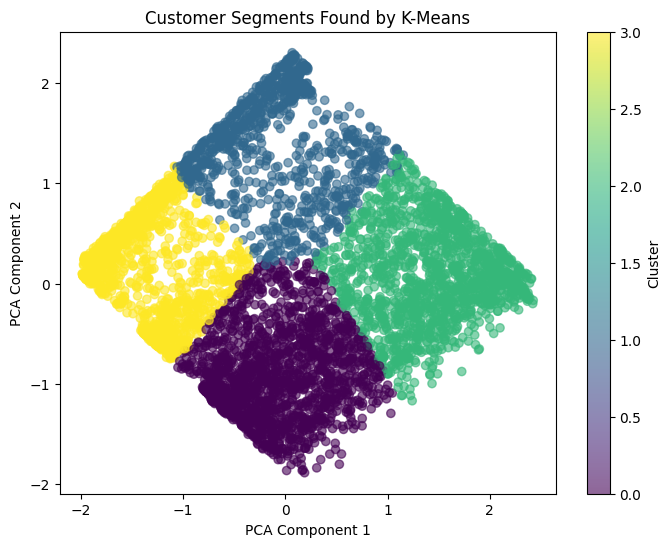

In [12]:
pca = PCA(n_components=2)
pca_result = pca.fit_transform(cluster_data)

plt.figure(figsize=(8, 6))
scatter = plt.scatter(pca_result[:, 0], pca_result[:, 1], c=cluster_labels, cmap='viridis', alpha=0.6)
plt.xlabel('PCA Component 1')
plt.ylabel('PCA Component 2')
plt.title('Customer Segments Found by K-Means')
plt.colorbar(scatter, label='Cluster')
plt.savefig('cluster_visualization.png', dpi=150, bbox_inches='tight')
plt.show()

### 3.4 Label and Interpret the Clusters

In [13]:
cluster_data_labeled = X_train.copy()  # unscaled values, easier to read
cluster_data_labeled['Cluster'] = cluster_labels
cluster_data_labeled['Churn'] = y_train.values

cluster_summary = cluster_data_labeled.groupby('Cluster')[['tenure', 'MonthlyCharges', 'Churn']].mean().round(2)
cluster_summary['Customer_Count'] = cluster_data_labeled.groupby('Cluster').size()
cluster_summary

,tenure,MonthlyCharges,Churn,Customer_Count
Cluster,,,,
0,14.86,81.07,0.49,1775
1,54.48,34.80,0.05,966
2,58.72,93.75,0.16,1512
3,10.51,32.09,0.25,1381


**Cluster labels, based on the table above:**

| Cluster | Avg. Tenure | Avg. Monthly Charges | Churn Rate | Label |
|---|---|---|---|---|
| 0 | Low (~15 mo) | High (~$81) | High (49%) | **At-Risk New Customers** — new, paying a lot, leaving often |
| 1 | High (~54 mo) | Low (~$35) | Very Low (5%) | **Loyal Low-Spend Customers** — long-standing, low bill, very stable |
| 2 | High (~59 mo) | High (~$94) | Low (16%) | **Long-Term High-Value Customers** — long-standing and high-paying, our best segment |
| 3 | Very Low (~11 mo) | Low (~$32) | Moderate (25%) | **New Budget Customers** — newly joined on cheaper plans |

The clearest pattern: **short tenure + high monthly charges (Cluster 0) has by far the highest churn (49%)**, while long tenure consistently pairs with low churn (Clusters 1 and 2, 5% and 16%). This suggests the first few months on an expensive plan are the highest-risk period for churn.

## Summary of Insights

- The dataset required no missing-value handling — it was already clean, but the check was still performed and documented as required.
- Categorical variables were encoded (binary mapping for 2-category columns, one-hot encoding for `Contract`), and only the two continuous features (`tenure`, `MonthlyCharges`) were scaled, using a scaler fit on the training set only to avoid data leakage.
- The elbow method pointed to **k = 4** as the optimal number of clusters.
- The 4 customer segments found range from a low-risk, long-tenure, high-value group to a high-risk group of new customers on expensive plans — the latter is the clearest target for retention efforts going into Stage 3.